In [1]:


!pip -q install -U xgboost shap

import warnings
warnings.filterwarnings("ignore")

import os
OUTPUT_DIR = "xgboost_workshop_outputs"
os.makedirs(OUTPUT_DIR, exist_ok=True)

print("Setup complete.")
print(f"All workshop outputs will be saved in: {OUTPUT_DIR}")

Setup complete.
All workshop outputs will be saved in: xgboost_workshop_outputs


In [2]:
# Import the libraries we will use

import json
import shutil
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from google.colab import files
from IPython.display import display

from sklearn.model_selection import train_test_split, KFold, RandomizedSearchCV
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

from xgboost import XGBRegressor

print("Libraries imported successfully.")

Libraries imported successfully.


In [3]:
# Upload dataset from your computer

uploaded = files.upload()

filename = list(uploaded.keys())[0]
print(f"Uploaded file: {filename}")

if filename.lower().endswith(".csv"):
    df = pd.read_csv(filename)
elif filename.lower().endswith((".xlsx", ".xls")):
    df = pd.read_excel(filename)
else:
    raise ValueError("Unsupported file format. Please upload a CSV, XLSX, or XLS file.")

print("\nDataset loaded successfully.")
print(f"Dataset shape: {df.shape[0]} rows × {df.shape[1]} columns")

display(df.head())

Saving Dataset_AI_ML_Workshop.csv to Dataset_AI_ML_Workshop.csv
Uploaded file: Dataset_AI_ML_Workshop.csv

Dataset loaded successfully.
Dataset shape: 184 rows × 14 columns


,Author,base_material,substrate_material,substrate_thermal_conductivity_W_mK,operational_pressure_kPa,wall_superheat_K,saturated_temperature_C,roughness_Ra,working_fluid,fluid_thermal_conductivity_W_mK,contact_angle_deg,CHF_kW_m2,p_crit_kPa,reduced_pressure
0,Kim_2020,Aluminum AA1050,Aluminum AA1050,237.0,101.3,32.00,56.0,0.081081,FC-72,0.056,15.93,159.9,1380.0,0.073406
1,Kim_2020,Aluminum AA1050,Aluminum AA1050,237.0,101.3,25.90,56.0,0.144144,FC-72,0.056,12.83,164.3,1380.0,0.073406
2,Kim_2020,Aluminum AA1050,Aluminum AA1050,237.0,101.3,21.17,56.0,0.252252,FC-72,0.056,12.63,191.8,1380.0,0.073406
3,Kim_2020,Aluminum AA1050,Aluminum AA1050,237.0,101.3,21.51,56.0,0.333333,FC-72,0.056,14.31,220.1,1380.0,0.073406
4,Kim_2020,Aluminum AA1050,Aluminum AA1050,237.0,101.3,22.00,56.0,0.513514,FC-72,0.056,13.77,202.6,1380.0,0.073406


In [4]:
# Rename important columns to a consistent format

rename_map = {
    "ks": "k_s",
    "kf": "k_f",
    "Tsat": "T_sat",
    "Ra": "R_a",
    "CHF": "qCHF",
    "substrate_thermal_conductivity_W_mK": "k_s",
    "fluid_thermal_conductivity_W_mK": "k_f",
    "operational_pressure_kPa": "P",
    "saturated_temperature_C": "T_sat",
    "roughness_Ra": "R_a",
    "CHF_kW_m2": "qCHF"
}

df = df.rename(columns={k: v for k, v in rename_map.items() if k in df.columns})

required_columns = ["k_s", "P", "T_sat", "R_a", "k_f", "qCHF"]
missing_columns = [col for col in required_columns if col not in df.columns]

if missing_columns:
    raise ValueError(
        f"These required columns are missing from the uploaded file: {missing_columns}\n"
        f"Available columns are: {list(df.columns)}"
    )

print("All required columns are present.\n")

overview_df = pd.DataFrame({
    "Column": required_columns,
    "Data type": [str(df[col].dtype) for col in required_columns],
    "Missing values": [int(df[col].isna().sum()) for col in required_columns]
})

display(overview_df)
display(df[required_columns].head())

All required columns are present.



,Column,Data type,Missing values
0,k_s,float64,0
1,P,float64,0
2,T_sat,float64,0
3,R_a,float64,0
4,k_f,float64,0
5,qCHF,float64,0


,k_s,P,T_sat,R_a,k_f,qCHF
0,237.0,101.3,56.0,0.081081,0.056,159.9
1,237.0,101.3,56.0,0.144144,0.056,164.3
2,237.0,101.3,56.0,0.252252,0.056,191.8
3,237.0,101.3,56.0,0.333333,0.056,220.1
4,237.0,101.3,56.0,0.513514,0.056,202.6


In [5]:

# Define features and target

feature_columns = ["k_s", "P", "T_sat", "R_a", "k_f"]
target_column = "qCHF"

X = df[feature_columns].copy()
y = df[target_column].astype(float).copy()

print("Feature matrix shape:", X.shape)
print("Target vector shape:", y.shape)

print("\nFeature preview:")
display(X.head())

print("\nTarget preview:")
display(y.head())


Feature matrix shape: (184, 5)
Target vector shape: (184,)

Feature preview:


,k_s,P,T_sat,R_a,k_f
0,237.0,101.3,56.0,0.081081,0.056
1,237.0,101.3,56.0,0.144144,0.056
2,237.0,101.3,56.0,0.252252,0.056
3,237.0,101.3,56.0,0.333333,0.056
4,237.0,101.3,56.0,0.513514,0.056



Target preview:


,qCHF
0,159.9
1,164.3
2,191.8
3,220.1
4,202.6


In [6]:

# Split data into training and testing sets

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    random_state=42
)

print("Train/test split completed.")
print(f"Training samples: {len(X_train)}")
print(f"Testing samples:  {len(X_test)}")

Train/test split completed.
Training samples: 147
Testing samples:  37


In [7]:

# Build a beginner-friendly XGBoost pipeline and tune it using randomized search

xgb_model = XGBRegressor(
    objective="reg:squarederror",
    tree_method="hist",   # efficient on CPU
    random_state=42,
    n_jobs=-1,
    verbosity=0
)

pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("model", xgb_model)
])

param_distributions = {
    "model__learning_rate": [0.04, 0.08, 0.10, 0.12, 0.15, 0.20],
    "model__n_estimators": [300, 500, 700, 1000, 1400],
    "model__max_depth": [3, 5, 7, 9, 11],
    "model__min_child_weight": [1, 3, 5, 7, 9],
    "model__colsample_bytree": [0.8, 0.9, 1.0],
    "model__subsample": [0.8, 0.9, 1.0],
    "model__reg_alpha": [0.0, 0.2, 0.5, 1.0],
    "model__reg_lambda": [0.1, 0.5, 1.0]
}

cv = KFold(n_splits=5, shuffle=True, random_state=42)

search = RandomizedSearchCV(
    estimator=pipeline,
    param_distributions=param_distributions,
    n_iter=20,  # reduced for workshop speed
    scoring="neg_root_mean_squared_error",
    cv=cv,
    n_jobs=-1,
    random_state=42,
    verbose=1,
    refit=True
)

search.fit(X_train, y_train)

best_pipe = search.best_estimator_

print("\nBest hyperparameters found:")
for k, v in search.best_params_.items():
    print(f"{k}: {v}")

Fitting 5 folds for each of 20 candidates, totalling 100 fits

Best hyperparameters found:
model__subsample: 1.0
model__reg_lambda: 1.0
model__reg_alpha: 0.2
model__n_estimators: 1000
model__min_child_weight: 1
model__max_depth: 7
model__learning_rate: 0.1
model__colsample_bytree: 1.0


In [8]:
import xgboost
import sklearn

print("xgboost version:", xgboost.__version__)
print("scikit-learn version:", sklearn.__version__)

xgboost version: 3.2.0
scikit-learn version: 1.6.1


In [9]:
# Predict on the test set and calculate performance metrics

y_pred = best_pipe.predict(X_test)

rmse = float(np.sqrt(mean_squared_error(y_test, y_pred)))
mae = float(mean_absolute_error(y_test, y_pred))
r2 = float(r2_score(y_test, y_pred))

summary_table = pd.DataFrame({
    "Metric": ["RMSE", "MAE", "R²"],
    "Value": [rmse, mae, r2]
})

print("Model performance on the test set:\n")
display(summary_table)

summary_table.to_csv(os.path.join(OUTPUT_DIR, "xgboost_metrics_summary.csv"), index=False)

Model performance on the test set:



,Metric,Value
0,RMSE,207.203046
1,MAE,139.082689
2,R²,0.925343


In [10]:

# Helper function to save figures

def save_current_figure(filename):
    full_path = os.path.join(OUTPUT_DIR, filename)
    plt.savefig(full_path, dpi=300, bbox_inches="tight")
    print(f"Saved: {full_path}")

Saved: xgboost_workshop_outputs/xgboost_predicted_vs_actual.jpg


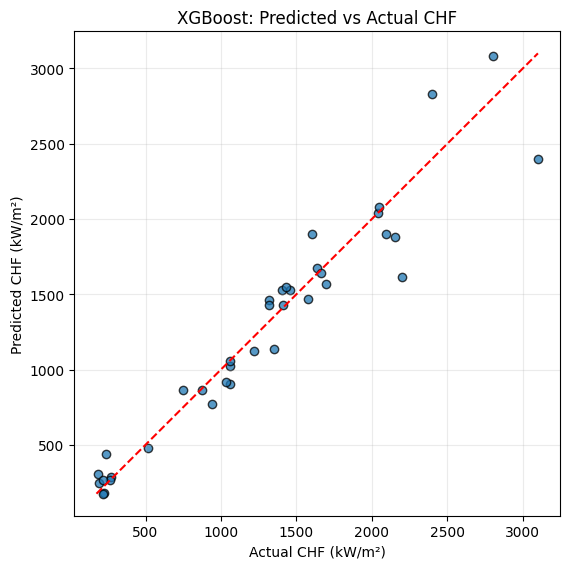

In [11]:
# Parity plot: Actual vs Predicted CHF

plt.figure(figsize=(5.8, 5.8))
plt.scatter(y_test, y_pred, alpha=0.75, edgecolor="black")

min_val = min(y_test.min(), y_pred.min())
max_val = max(y_test.max(), y_pred.max())

plt.plot([min_val, max_val], [min_val, max_val], "r--", linewidth=1.5)

plt.xlabel("Actual CHF (kW/m²)")
plt.ylabel("Predicted CHF (kW/m²)")
plt.title("XGBoost: Predicted vs Actual CHF")
plt.grid(alpha=0.25)
plt.tight_layout()

save_current_figure("xgboost_predicted_vs_actual.jpg")
plt.show()


Saved: xgboost_workshop_outputs/xgboost_residual_plot.jpg


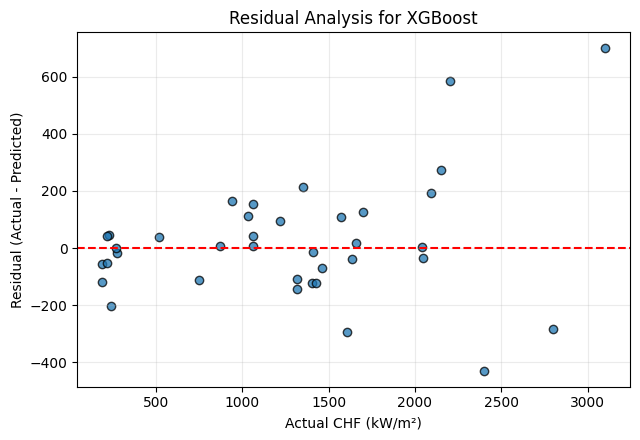

In [12]:
# Residual plot

residuals = y_test - y_pred

plt.figure(figsize=(6.5, 4.5))
plt.scatter(y_test, residuals, alpha=0.75, edgecolor="black")
plt.axhline(0, color="red", linestyle="--", linewidth=1.5)

plt.xlabel("Actual CHF (kW/m²)")
plt.ylabel("Residual (Actual - Predicted)")
plt.title("Residual Analysis for XGBoost")
plt.grid(alpha=0.25)
plt.tight_layout()

save_current_figure("xgboost_residual_plot.jpg")
plt.show()

Feature importance table:



,Feature,Importance
2,T_sat,0.692581
4,k_f,0.188637
1,P,0.097077
3,R_a,0.011299
0,k_s,0.010406


Saved: xgboost_workshop_outputs/xgboost_feature_importance.jpg


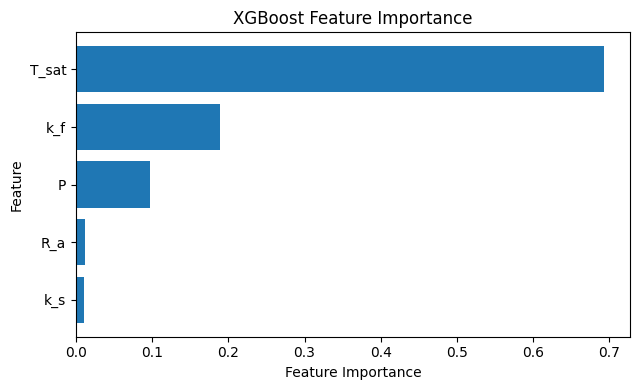

In [13]:

# Feature importance plot

trained_model = best_pipe.named_steps["model"]

importance_df = pd.DataFrame({
    "Feature": feature_columns,
    "Importance": trained_model.feature_importances_
}).sort_values("Importance", ascending=False)

print("Feature importance table:\n")
display(importance_df)

plt.figure(figsize=(6.5, 4.0))
plt.barh(
    importance_df["Feature"][::-1],
    importance_df["Importance"][::-1]
)

plt.xlabel("Feature Importance")
plt.ylabel("Feature")
plt.title("XGBoost Feature Importance")
plt.tight_layout()

save_current_figure("xgboost_feature_importance.jpg")
plt.show()

Saved: xgboost_workshop_outputs/shap_global_importance_bar.jpg


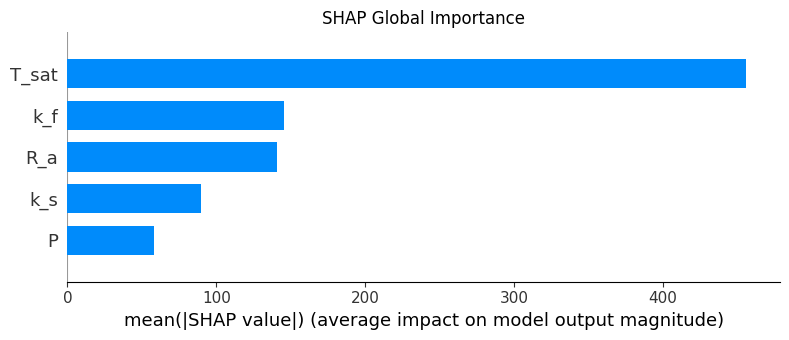

Saved: xgboost_workshop_outputs/shap_beeswarm.jpg


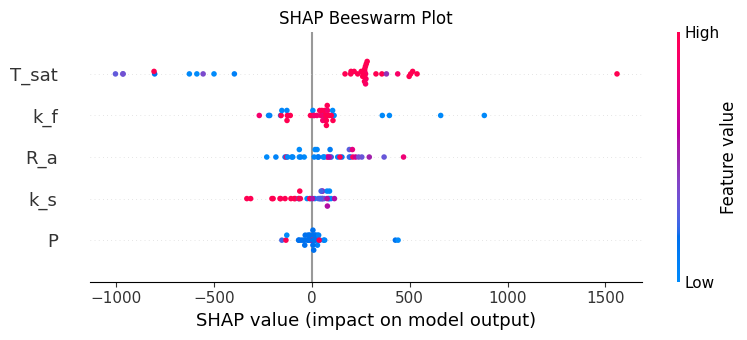

In [14]:

# Optional SHAP analysis

import shap

imputer = best_pipe.named_steps["imputer"]
trained_model = best_pipe.named_steps["model"]

X_test_imputed = pd.DataFrame(
    imputer.transform(X_test),
    columns=feature_columns
)

try:
    explainer = shap.TreeExplainer(trained_model)
    shap_output = explainer(X_test_imputed)
    shap_values = shap_output.values if hasattr(shap_output, "values") else shap_output
except Exception:
    explainer = shap.Explainer(trained_model, X_test_imputed)
    shap_output = explainer(X_test_imputed)
    shap_values = shap_output.values

# SHAP bar plot
plt.figure(figsize=(7, 4))
shap.summary_plot(shap_values, X_test_imputed, plot_type="bar", show=False)
plt.title("SHAP Global Importance")
plt.tight_layout()
save_current_figure("shap_global_importance_bar.jpg")
plt.show()

# SHAP beeswarm plot
plt.figure(figsize=(7, 4))
shap.summary_plot(shap_values, X_test_imputed, show=False)
plt.title("SHAP Beeswarm Plot")
plt.tight_layout()
save_current_figure("shap_beeswarm.jpg")
plt.show()

Saved: xgboost_workshop_outputs/learning_rate_sensitivity_xgb.jpg


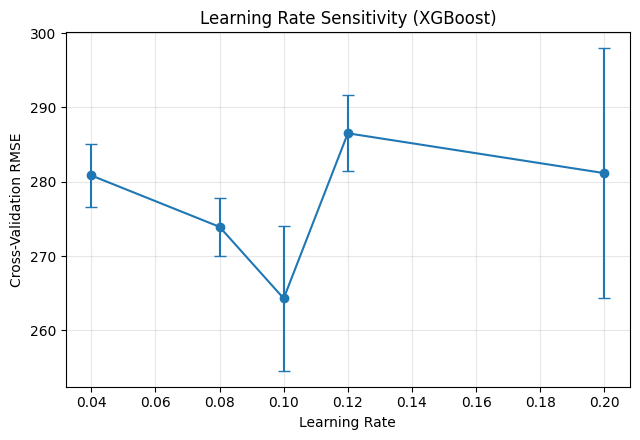

Saved: xgboost_workshop_outputs/max_depth_sensitivity_xgb.jpg


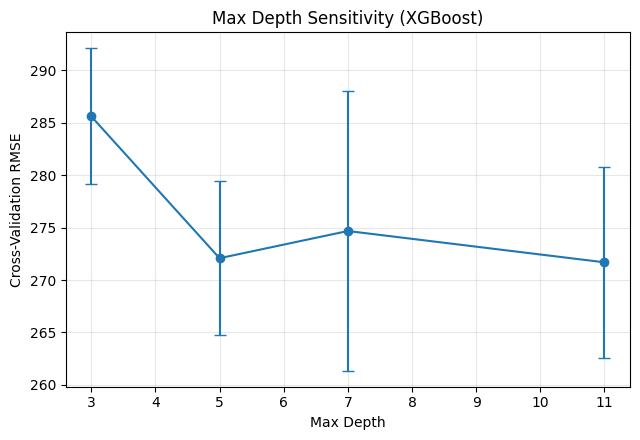

In [15]:

# Hyperparameter sensitivity plots using CV results

cv_results = pd.DataFrame(search.cv_results_)

results_df = pd.DataFrame({
    "mean_test_score": cv_results["mean_test_score"],
    "std_test_score": cv_results["std_test_score"],
    "learning_rate": cv_results["param_model__learning_rate"].astype(float),
    "max_depth": cv_results["param_model__max_depth"].astype(int)
})

results_df["mean_RMSE"] = -results_df["mean_test_score"]

lr_group = results_df.groupby("learning_rate", as_index=False).agg(
    mean_RMSE=("mean_RMSE", "mean"),
    std_RMSE=("mean_RMSE", "std")
)

depth_group = results_df.groupby("max_depth", as_index=False).agg(
    mean_RMSE=("mean_RMSE", "mean"),
    std_RMSE=("mean_RMSE", "std")
)

# Learning rate sensitivity
plt.figure(figsize=(6.5, 4.5))
plt.errorbar(
    lr_group["learning_rate"],
    lr_group["mean_RMSE"],
    yerr=lr_group["std_RMSE"],
    fmt="-o",
    capsize=4
)
plt.xlabel("Learning Rate")
plt.ylabel("Cross-Validation RMSE")
plt.title("Learning Rate Sensitivity (XGBoost)")
plt.grid(alpha=0.3)
plt.tight_layout()
save_current_figure("learning_rate_sensitivity_xgb.jpg")
plt.show()

# Max depth sensitivity
plt.figure(figsize=(6.5, 4.5))
plt.errorbar(
    depth_group["max_depth"],
    depth_group["mean_RMSE"],
    yerr=depth_group["std_RMSE"],
    fmt="-o",
    capsize=4
)
plt.xlabel("Max Depth")
plt.ylabel("Cross-Validation RMSE")
plt.title("Max Depth Sensitivity (XGBoost)")
plt.grid(alpha=0.3)
plt.tight_layout()
save_current_figure("max_depth_sensitivity_xgb.jpg")
plt.show()

In [16]:

# Save final tables and download everything as a zip file

predictions_df = X_test.copy()
predictions_df["Actual_qCHF"] = y_test.values
predictions_df["Predicted_qCHF"] = y_pred
predictions_df["Residual"] = y_test.values - y_pred

predictions_path = os.path.join(OUTPUT_DIR, "xgboost_test_predictions.csv")
predictions_df.to_csv(predictions_path, index=False)

best_params_clean = {}
for k, v in search.best_params_.items():
    key = k.replace("model__", "")
    if isinstance(v, (np.integer,)):
        best_params_clean[key] = int(v)
    elif isinstance(v, (np.floating,)):
        best_params_clean[key] = float(v)
    else:
        best_params_clean[key] = v

params_path = os.path.join(OUTPUT_DIR, "best_xgboost_params.json")
with open(params_path, "w") as f:
    json.dump(best_params_clean, f, indent=2)

zip_path = shutil.make_archive("xgboost_workshop_results", "zip", OUTPUT_DIR)

print("Saved files:")
print(f"- {predictions_path}")
print(f"- {params_path}")
print(f"- {zip_path}")

files.download(zip_path)

Saved files:
- xgboost_workshop_outputs/xgboost_test_predictions.csv
- xgboost_workshop_outputs/best_xgboost_params.json
- /content/xgboost_workshop_results.zip


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>